# Random MIMIC Note Summaries and Compression Ratios

This notebook samples 10 random notes from `datasets/mimic-iii-ext-notes-1.0.0/notes.csv`, generates structured clinical summaries with `ClinicalSummarizer`, and reports per-note compression ratios.

- Dataset assumption: this uses the local MIMIC-derived mini dataset in the repo.
- Runtime note: the summarization cell runs the local MLX model 10 times, so expect it to take a while.

In [1]:
import json
import sys
from pathlib import Path
import re

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "clinical_summarization.py").exists()
            and (candidate / "datasets/mimic-iii-ext-notes-1.0.0/notes.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the LLMS repo root from the current notebook working directory."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from clinical_summarization import ClinicalSummarizer, ClinicalSummarizerConfig
from prompts import CLINICAL_SUMMARY_END_MARKER

DATASET_PATH = REPO_ROOT / "datasets" / "mimic-iii-ext-notes-1.0.0" / "notes.csv"
OUTPUT_JSON_PATH = REPO_ROOT / "notebooks" / "artifacts" / "mimic_random_10_summaries_compression_results.json"
SAMPLE_SIZE = 10
RANDOM_SEED = 42
TARGET_COMPRESSION_RATIO = 0.18  # Set to None to use the summarizer's built-in heuristic.
MODEL_PATH = "mlx-community/Qwen3.5-9B-4bit"

pd.set_option("display.max_colwidth", 120)


def count_words(text: str) -> int:
    return len(re.findall(r"\S+", text or ""))


def preview(text: str, max_chars: int = 500) -> str:
    collapsed = re.sub(r"\s+", " ", text or "").strip()
    if len(collapsed) <= max_chars:
        return collapsed
    return collapsed[: max_chars - 3] + "..."


def strip_terminal_marker(text: str) -> str:
    stripped = (text or "").rstrip()
    if stripped.endswith(CLINICAL_SUMMARY_END_MARKER):
        return stripped[: -len(CLINICAL_SUMMARY_END_MARKER)].rstrip()
    return stripped


In [2]:
notes_df = pd.read_csv(DATASET_PATH)
sample_df = notes_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Loaded {len(notes_df)} notes from {DATASET_PATH}.")
print(f"Sampling {SAMPLE_SIZE} notes with random_state={RANDOM_SEED}.")

sample_df[["row_id", "hadm_id", "subject_id"]]


Loaded 150 notes from /Users/natejly/Documents/GitHub/LLMS/datasets/mimic-iii-ext-notes-1.0.0/notes.csv.
Sampling 10 notes with random_state=42.


,row_id,hadm_id,subject_id
0,701538,169374,59113
1,598031,165594,54229
2,402992,187638,4843
3,644019,180716,60739
4,481041,192782,56635
5,329634,195382,1860
6,411906,113344,88081
7,366962,146690,16975
8,545713,171649,60316
9,520384,165405,72907


In [3]:
config = ClinicalSummarizerConfig(
    model_path=MODEL_PATH,
    target_compression_ratio=TARGET_COMPRESSION_RATIO,
    verbose=False,
)
summarizer = ClinicalSummarizer(config)
summarizer


In [4]:
results = []

for idx, row in sample_df.iterrows():
    row_id = int(row["row_id"])
    hadm_id = int(row["hadm_id"])
    subject_id = int(row["subject_id"])
    note_text = row["text"]

    summary = summarizer.summarize_text(
        note_text,
        patient_id=str(hadm_id),
        note_type="mimic clinical note",
        source=f"{DATASET_PATH}:{row_id}",
    )
    cleaned_summary = strip_terminal_marker(summary)

    source_words = count_words(note_text)
    summary_words = count_words(cleaned_summary)
    compression_ratio = summary_words / source_words if source_words else float("nan")
    target_ratio_label = (
        f"{TARGET_COMPRESSION_RATIO:.1%}" if TARGET_COMPRESSION_RATIO is not None else "heuristic"
    )

    print(
        f"[{idx + 1}/{len(sample_df)}] row_id={row_id}, hadm_id={hadm_id} "
        f"target={target_ratio_label}, actual={compression_ratio:.1%} "
        f"({summary_words}/{source_words} words)"
    )

    results.append(
        {
            "row_id": row_id,
            "hadm_id": hadm_id,
            "subject_id": subject_id,
            "target_compression_ratio": TARGET_COMPRESSION_RATIO,
            "source_words": source_words,
            "summary_words": summary_words,
            "compression_ratio": compression_ratio,
            "compression_percent": compression_ratio * 100,
            "reduction_percent": (1 - compression_ratio) * 100,
            "source_note": note_text,
            "source_preview": preview(note_text),
            "summary": cleaned_summary,
        }
    )

results_df = pd.DataFrame(results)
results_df


/Users/natejly/Documents/GitHub/LLMS/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 135300.13it/s]


[1/10] row_id=701538, hadm_id=169374 target=18.0%, actual=22.7% (58/255 words)
[2/10] row_id=598031, hadm_id=165594 target=18.0%, actual=12.6% (44/349 words)
[3/10] row_id=402992, hadm_id=187638 target=18.0%, actual=17.5% (55/315 words)
[4/10] row_id=644019, hadm_id=180716 target=18.0%, actual=15.3% (66/430 words)
[5/10] row_id=481041, hadm_id=192782 target=18.0%, actual=13.8% (77/559 words)
[6/10] row_id=329634, hadm_id=195382 target=18.0%, actual=17.1% (61/356 words)
[7/10] row_id=411906, hadm_id=113344 target=18.0%, actual=14.7% (60/408 words)
[8/10] row_id=366962, hadm_id=146690 target=18.0%, actual=11.3% (53/467 words)
[9/10] row_id=545713, hadm_id=171649 target=18.0%, actual=17.3% (54/313 words)
[10/10] row_id=520384, hadm_id=165405 target=18.0%, actual=15.9% (78/490 words)


,row_id,hadm_id,subject_id,target_compression_ratio,source_words,summary_words,compression_ratio,compression_percent,reduction_percent,source_note,source_preview,summary
0,701538,169374,59113,0.18,255,58,0.227451,22.745098,77.254902,Mr. [**Known lastname **] is a 81 yo [**Country 4486**] speaking only man. He has a recent diagnosis of HIV ([**...,Mr. [**Known lastname **] is a 81 yo [**Country 4486**] speaking only man. He has a recent diagnosis of HIV ([**7-31...,"Brief Hospital Course:\n81yo male admitted MICU for septic shock (HIV, C. diff, adrenal insufficiency, MDS) with hyp..."
1,598031,165594,54229,0.18,349,44,0.126074,12.607450,87.392550,"Mr. [**Known lastname 8498**] is a 73 yoM on HD-anuric, h/o AFib not currently on coumadin (though is on at home)...","Mr. [**Known lastname 8498**] is a 73 yoM on HD-anuric, h/o AFib not currently on coumadin (though is on at home), w...",Brief Hospital Course:\n73yoM transferred from neurology for resp distress/hypoxia post-fall SDH.\nAdmitted 2021-08-...
2,402992,187638,4843,0.18,315,55,0.174603,17.460317,82.539683,"49 year old female with DM, HTN, CAD s/p 5-vessel CABG and PCI, presented with L leg erythema/pain/swelling, feve...","49 year old female with DM, HTN, CAD s/p 5-vessel CABG and PCI, presented with L leg erythema/pain/swelling, fever, ...","Brief Hospital Course:\n49F DM/HTN/CAD s/p CABG/PCI presented with LLE erythema, fever, rigors.\nAdmitted for sepsis..."
3,644019,180716,60739,0.18,430,66,0.153488,15.348837,84.651163,87 yo male adm [**12-4**] with NSTEMI w/ new diastolic CHF in setting of GIB. MI medically managed. IV lasix gtt ...,87 yo male adm [**12-4**] with NSTEMI w/ new diastolic CHF in setting of GIB. MI medically managed. IV lasix gtt for...,"Brief Hospital Course:\n87M admitted 12-4 with NSTEMI, new diastolic CHF, GIB.\nCHF resolved per CXR; MI medically m..."
4,481041,192782,56635,0.18,559,77,0.137746,13.774597,86.225403,Ms. [**Known lastname 861**] is a 81 year old woman admitted to T/SICU from the OR following a subtotal colectomy...,Ms. [**Known lastname 861**] is a 81 year old woman admitted to T/SICU from the OR following a subtotal colectomy wi...,"Brief Hospital Course:\n81yo F admitted for NSTEMI, RCA PCI with groin hematoma.\nDeveloped rapid AFib, converted to..."
5,329634,195382,1860,0.18,356,61,0.171348,17.134831,82.865169,"Chief Complaint: hypotension HPI: 70yo f w SCLC, DMII/HTN/Hyperlipidemia, afib on coumadin, ESRD 2' previo...","Chief Complaint: hypotension HPI: 70yo f w SCLC, DMII/HTN/Hyperlipidemia, afib on coumadin, ESRD 2' previous cisplat...","Brief Hospital Course:\n70yo f w SCLC, DM2, HTN, ESRD transferred for hypotension.\nInitial workup showed large righ..."
6,411906,113344,88081,0.18,408,60,0.147059,14.705882,85.294118,"Pt is a 74 yo admitted to MICU 6 with PMH of HTN, Hypothyroidism, gallstones, and hyperlipidemia who presented to...","Pt is a 74 yo admitted to MICU 6 with PMH of HTN, Hypothyroidism, gallstones, and hyperlipidemia who presented to ED...","Brief Hospital Course:\n74yo F admitted MICU with ovarian CA, AKI, hypovolemic shock, bilateral pleural effusions.\n..."
7,366962,146690,16975,0.18,467,53,0.113490,11.349036,88.650964,"This is an 80 yo female w/PMed Hx of CAD, CABG, DMwho came from the heb Reb with SOB. At Heb Reb she had 1 week ...","This is an 80 yo female w/PMed Hx of CAD, CABG, DMwho came from the heb Reb with SOB. At Heb Reb she had 1 week of f...","Brief Hospital Course:\n80yo F admitted for SOB, fever, AMS, Hx pneumonia.\nTemp 100.8, HTN 163/73, HR 101, SpO2 99%..."
8,545713,171649,60316,0.18,313,54,0.172524,17.252396,82.747604,This is a 71 y.o male with 6 week hx. Of diarrhea (non bloody) and weakness. Pt. underwent screening colonoscopy ...,This is a 71 y.o male with 6 week hx. Of diarrhea (non bloody) and weakness. Pt. underwent screening colonoscopy on ...,Brief Hospital Course:\n71M with 6-wk diarrhea/weakness admitted for obstructing hepatic flexure mass.\nFailed extub...
9,520384,165405,72907,0.18,

In [5]:
OUTPUT_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)

export_payload = {
    "dataset_path": str(DATASET_PATH),
    "model_path": MODEL_PATH,
    "sample_size": SAMPLE_SIZE,
    "random_seed": RANDOM_SEED,
    "target_compression_ratio": TARGET_COMPRESSION_RATIO,
    "results": results,
}

OUTPUT_JSON_PATH.write_text(json.dumps(export_payload, indent=2), encoding="utf-8")
print(f"Wrote JSON results to {OUTPUT_JSON_PATH}")
display({
    "row_id": export_payload["results"][0]["row_id"],
    "source_note": preview(export_payload["results"][0]["source_note"], max_chars=250),
    "summary": preview(export_payload["results"][0]["summary"], max_chars=250),
})


Wrote JSON results to /Users/natejly/Documents/GitHub/LLMS/notebooks/artifacts/mimic_random_10_summaries_compression_results.json


{'row_id': 701538,
 'source_note': 'Mr. [**Known lastname **] is a 81 yo [**Country 4486**] speaking only man. He has a recent diagnosis of HIV ([**7-31**]), has C.diff with leukocytosis in 40s, adrenal insufficiency, MDS(prbc and plt transfusion dependent), worsening acidosis and r...',
 'summary': 'Brief Hospital Course: 81yo male admitted MICU for septic shock (HIV, C. diff, adrenal insufficiency, MDS) with hypotension, lactate 5, and lactic acidosis. Workup revealed DVT (left leg clots), AKI (Cr 2.7, BUN 81), and severe sepsis (temp 95-96F...'}

In [6]:
summary_stats = pd.Series(
    {
        "sample_size": len(results_df),
        "mean_source_words": round(results_df["source_words"].mean(), 1),
        "mean_summary_words": round(results_df["summary_words"].mean(), 1),
        "mean_compression_ratio": round(results_df["compression_ratio"].mean(), 3),
        "median_compression_ratio": round(results_df["compression_ratio"].median(), 3),
        "min_compression_ratio": round(results_df["compression_ratio"].min(), 3),
        "max_compression_ratio": round(results_df["compression_ratio"].max(), 3),
    }
)

display(summary_stats.to_frame(name="value"))
display(
    results_df[
        [
            "row_id",
            "hadm_id",
            "subject_id",
            "source_words",
            "summary_words",
            "compression_ratio",
            "reduction_percent",
        ]
    ].sort_values("compression_ratio")
)


,value
sample_size,10.000
mean_source_words,394.200
mean_summary_words,60.600
mean_compression_ratio,0.158
median_compression_ratio,0.156
min_compression_ratio,0.113
max_compression_ratio,0.227


,row_id,hadm_id,subject_id,source_words,summary_words,compression_ratio,reduction_percent
7,366962,146690,16975,467,53,0.113490,88.650964
1,598031,165594,54229,349,44,0.126074,87.392550
4,481041,192782,56635,559,77,0.137746,86.225403
6,411906,113344,88081,408,60,0.147059,85.294118
3,644019,180716,60739,430,66,0.153488,84.651163
9,520384,165405,72907,490,78,0.159184,84.081633
5,329634,195382,1860,356,61,0.171348,82.865169
8,545713,171649,60316,313,54,0.172524,82.747604
2,402992,187638,4843,315,55,0.174603,82.539683
0,701538,169374,59113,255,58,0.227451,77.254902


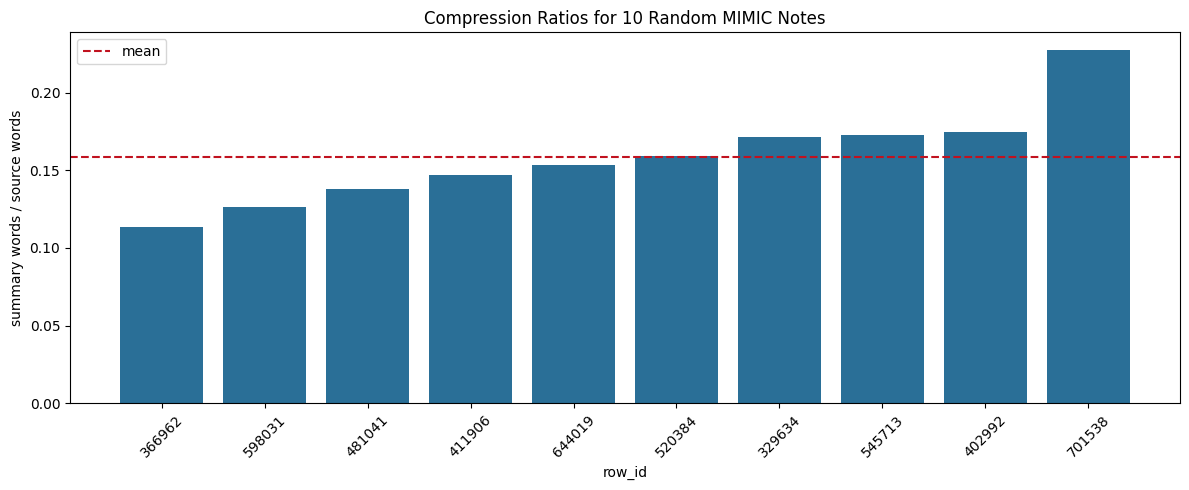

In [7]:
import matplotlib.pyplot as plt

plot_df = results_df.sort_values("compression_ratio").copy()
plot_df["label"] = plot_df["row_id"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["compression_ratio"], color="#2a6f97")
plt.axhline(plot_df["compression_ratio"].mean(), color="#c1121f", linestyle="--", label="mean")
plt.ylabel("summary words / source words")
plt.xlabel("row_id")
plt.title("Compression Ratios for 10 Random MIMIC Notes")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
for row in results_df.sort_values("compression_ratio").itertuples(index=False):
    display(
        Markdown(
            f"""
### row_id={row.row_id} | hadm_id={row.hadm_id} | subject_id={row.subject_id}

**Compression ratio:** {row.compression_ratio:.1%} ({row.summary_words} / {row.source_words} words)

**Source preview**
```
{row.source_preview}
```

**Summary**
{row.summary}
"""
        )
    )



### row_id=366962 | hadm_id=146690 | subject_id=16975

**Compression ratio:** 11.3% (53 / 467 words)

**Source preview**
```
This is an 80 yo female w/PMed Hx of CAD, CABG, DMwho came from the heb Reb with SOB. At Heb Reb she had 1 week of fevers and altered mental status, her alter MS coincided with the administration of baclofen and dilaudid these were D/Ced. On [**3-8**] her 02 SAT was 80% on RA and 90% on 3 liters; this initiated her transfer to [**Hospital1 54**]. In the EW her temp was 100.8, 163/73,101, 18 99% on 3 liters. An EKG showed 1mm ST depressions in V4-5, BNP was 4005 and her CXR showed multifocal p...
```

**Summary**
Brief Hospital Course:
80yo F admitted for SOB, fever, AMS, Hx pneumonia.
Temp 100.8, HTN 163/73, HR 101, SpO2 99% on 3L O2.
EKG 1mm ST depressions V4-5; BNP 4005; CXR multifocal pneumonia.
TTE diastolic dysfunction; MI ruled out.
Maxed O2 95% HFNC; tachypnea 40; restless.
Plan A-line, CT, BAL; likely intubation.
PICC



### row_id=598031 | hadm_id=165594 | subject_id=54229

**Compression ratio:** 12.6% (44 / 349 words)

**Source preview**
```
Mr. [**Known lastname 8498**] is a 73 yoM on HD-anuric, h/o AFib not currently on coumadin (though is on at home), who is being transferred from the neurology service for respiratory distress and hypoxia. He was admitted on [**2191-8-12**] after a fall resulting in acute on chronic SDH on the left; his course is complicated by seizure and he has been started on fosphenytoin & phenytoin. . This evening he was noted to be in acute respiratory distress with desats to the low to mid 90's on 3LNC ...
```

**Summary**
Brief Hospital Course:
73yoM transferred from neurology for resp distress/hypoxia post-fall SDH.
Admitted 2021-08-12 with acute on chronic SDH left, seizure, fever.
Treated with fosphenytoin/phenytoin, vanco/genta, vasopressors.
Brief MICU stay 08-17 to 08-18 for hypotension/fever.
Currently ventilated, febrile, hypotensive, anuric on HD.

Diagnoses:
Acute



### row_id=481041 | hadm_id=192782 | subject_id=56635

**Compression ratio:** 13.8% (77 / 559 words)

**Source preview**
```
Ms. [**Known lastname 861**] is a 81 year old woman admitted to T/SICU from the OR following a subtotal colectomy with an end ileostomy for bowel ischemia. *admitted to [**Hospital1 19**] [**8-5**] for NSTEMI Mi, cath d and angioplasty done of RCA (had R groin hematoma post procedure) *on [**8-12**] had rapid afib (rate to 150 s), converted to sinus with digoxin and then 30 minutes after confusion began complaining of abdominal pain. CT of abdomen done and was concerning for ischemic bowel. T...
```

**Summary**
Brief Hospital Course:
81yo F admitted for NSTEMI, RCA PCI with groin hematoma.
Developed rapid AFib, converted to SR with digoxin.
Admitted for bowel ischemia, subtotal colectomy, end ileostomy.
Post-op developed rapid AFib, hypotension, failed cardioversion.
Cardioverted with amiodarone, converted to SR.
Pressors weaned from levophed to norepinephrine.
Discharged to home or rehab pending disposition.

Diagnoses:
Acute NSTEMI, RCA angioplasty, groin hematoma.
Atrial fibrillation with rapid ventricular response.
Bowel ischemia, subtotal colectomy, end ileostomy.
Acute kidney injury



### row_id=411906 | hadm_id=113344 | subject_id=88081

**Compression ratio:** 14.7% (60 / 408 words)

**Source preview**
```
Pt is a 74 yo admitted to MICU 6 with PMH of HTN, Hypothyroidism, gallstones, and hyperlipidemia who presented to ED from home with c/o increasing LE edema, increasing SOB over last few days. Pt recently dx. with ovarian CA vs. Lymphoma and is undergoing workup work-up to date shows ovarian adenocarcinoma, all data is not in yet. Pre-admission abdominal CT with dye load and recent labs revealed worsening kidney failure so PCP [**Name (NI) 167**] pt at home and sent pt directly to ED. On admis...
```

**Summary**
Brief Hospital Course:
74yo F admitted MICU with ovarian CA, AKI, hypovolemic shock, bilateral pleural effusions.
Presented with LE edema, SOB; pre-admission CT showed worsening renal failure.
Admitted with BUN 116, Cr 7.2, K 7.8, hypoxia; received kayexalate, insulin, D50, calcium.
Thoracentesis yielded 1L bloody fluid; chest tube placed.
Started CRRT for fluid overload; weaned levophed due to hypotension.
2nd



### row_id=644019 | hadm_id=180716 | subject_id=60739

**Compression ratio:** 15.3% (66 / 430 words)

**Source preview**
```
87 yo male adm [**12-4**] with NSTEMI w/ new diastolic CHF in setting of GIB. MI medically managed. IV lasix gtt for CHF, now resolved per CXR. Sent to [**Hospital Ward Name 383**] 3 for a few days until [**12-11**] when temp spiked to 104 PR. Pt found to have C-diff colitis. Abd CT with severe pancolitis versus walled-off bowel perforation. Surgery following- no need for urgent bowel surgery. NPO until further notice for bowel rest. Pt still awaiting PICC placement for TPN. IV nurse [**First...
```

**Summary**
Brief Hospital Course:
87M admitted 12-4 with NSTEMI, new diastolic CHF, GIB.
CHF resolved per CXR; MI medically managed.
Temp spiked 104 PR 12-11; C. diff colitis diagnosed.
Abd CT showed severe pancolitis vs walled-off perforation.
No urgent bowel surgery needed; NPO for bowel rest.
PICC placed 12-17 but coiled on CXR; line left in place.
Awaiting IR advancement tomorrow for PICC repair.
Has not eaten



### row_id=520384 | hadm_id=165405 | subject_id=72907

**Compression ratio:** 15.9% (78 / 490 words)

**Source preview**
```
Patient w/ recent hx of ERCP; Had an elective lap chole on [**1-22**] at [**Hospital **] [**Hospital **] Hospital and post op was admitted to the floor; on POD #1 pt had increasing abdominal pain, became hypotensive with decreased uop. Patient taken back to the OR for an ex lap- found a cystic stump leak from clips falling off postop; her small bowel was also dusky and she underwent a SBR;; patient was transferred to TSICU for further management of care on [**1-24**]. aggressive resuscitation...
```

**Summary**
Brief Hospital Course:
- Post-op day 1 developed abdominal pain, hypotension, decreased urine output.
- Exploratory lap found cystic stump leak, dusky small bowel; underwent SBR.
- Transferred to TSICU; returned OR for ischemic bowel resection and colectomy.
- Day 1-26 underwent multiple bowel resections, anastomosis, ileostomy, hysterectomy.
- Day 27 started CVVH for worsening renal failure; stopped day 29 due to hypotension.
- Intubated day 5; remains on full ventilator support with PEEP 10.
- Persistent seps



### row_id=329634 | hadm_id=195382 | subject_id=1860

**Compression ratio:** 17.1% (61 / 356 words)

**Source preview**
```
Chief Complaint: hypotension HPI: 70yo f w SCLC, DMII/HTN/Hyperlipidemia, afib on coumadin, ESRD 2' previous cisplatin therapy, transferred to unit for hypotension. . Hosp course initially p/w SOB and found to have large right pleural effusion. Tapped (transudative on [**6-25**]). On [**7-13**], had right mainstem bronch stent placed. This was c/b hypoxic resp failure and need for intubation. She was in the ICU and underwent [**Initials (NamePattern4) **] [**Last Name (NamePattern4) **] on [*...
```

**Summary**
Brief Hospital Course:
70yo f w SCLC, DM2, HTN, ESRD transferred for hypotension.
Initial workup showed large right pleural effusion (transudative).
Right mainstem bronch stent placed for hypoxic resp failure.
Developed constipation, rising WBC, and suspected postob PNA.
Treated with vanco/levaquin; remained stable on floor.
Acute worsening abd pain, SBP 60s, lactate 2.6.
CT abd showed ileus, RLL consolidation with effusion.



### row_id=545713 | hadm_id=171649 | subject_id=60316

**Compression ratio:** 17.3% (54 / 313 words)

**Source preview**
```
This is a 71 y.o male with 6 week hx. Of diarrhea (non bloody) and weakness. Pt. underwent screening colonoscopy on [**11-1**] which revealed an obstructing/bleeding hepatic flexure mass. Bx done at that time. PMhx. CHF, HTN, Hyperlipedemia, COPD, DM II, ischemic heart dz., s/p CABG x2 in [**2158**]. Today Pt. went to OR for scheduled lap colectomy that turned into open colectomy. Pt. failed extubation in OR and reintubated there. Also Pt. had been hypotensive to 60 s systolic and non respons...
```

**Summary**
Brief Hospital Course:
71M with 6-wk diarrhea/weakness admitted for obstructing hepatic flexure mass.
Failed extubation post open colectomy; hypotensive to 60s SBP refractory to norepi.
Received 40 mg IV lasix for CHF; intubated on A/C 460x14 PEEP5 60% FiO2.
Vent switched to CPAP 5/5 40%; BP stabilized >100s SBP.

Diagnoses:
Obstructive hepatic flexure mass



### row_id=402992 | hadm_id=187638 | subject_id=4843

**Compression ratio:** 17.5% (55 / 315 words)

**Source preview**
```
49 year old female with DM, HTN, CAD s/p 5-vessel CABG and PCI, presented with L leg erythema/pain/swelling, fever, nausea/vomiting since Wednesday. In the ED she had a temp to 102.1 with rigors (was given Motrin and tylenol) and was started on Vanc/Zosyn for presumptive LLE cellulitis and admitted to medicine. Labs pertinent for CBC with left shift, [**Last Name (un) **], hyponatremia and elevated lactate. Blood cultures grew out STAPH AUREUS COAG + (MSSA) (4/4 bottles). Hospital course comp...
```

**Summary**
Brief Hospital Course:
49F DM/HTN/CAD s/p CABG/PCI presented with LLE erythema, fever, rigors.
Admitted for sepsis (MSSA bacteremia) and hypotension.
Transferred to MICU; off pressors.
MRI negative for acute stroke.
Consults: vascular (diabetic soft tissue infection), podiatry (Charcot foot).

Diagnoses:
Sepsis, MSSA bacteremia, Acute kidney injury, Left lower extremity infection,
Charcot foot.

Procedures / interventions:



### row_id=701538 | hadm_id=169374 | subject_id=59113

**Compression ratio:** 22.7% (58 / 255 words)

**Source preview**
```
Mr. [**Known lastname **] is a 81 yo [**Country 4486**] speaking only man. He has a recent diagnosis of HIV ([**7-31**]), has C.diff with leukocytosis in 40s, adrenal insufficiency, MDS(prbc and plt transfusion dependent), worsening acidosis and renal failure due to ATN. He also has L leg pain and erythema. Admit to the MICU for hypotension and lactate 5. Acute Pain Assessment: Pt with pain to his lt leg when touched.Has got patches of erythmatous areas on his lt leg and both groin. Action: M...
```

**Summary**
Brief Hospital Course:
81yo male admitted MICU for septic shock (HIV, C. diff, adrenal insufficiency, MDS) with hypotension, lactate 5, and lactic acidosis.
Workup revealed DVT (left leg clots), AKI (Cr 2.7, BUN 81), and severe sepsis (temp 95-96F).
Treated with morphine, 2 units PRBC (Hct 28.8), IV abx, Bair Hugger, and renal consult; heparin held due to
